In [2]:
import joblib 
from utils.utils_2 import plot_most_accurate_window_angle_lstm, plot_most_accurate_window_lstm, visualize_attention_single_angle

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
# See the first few rows
# bend_columns = [col for col in dfs.columns if 'BEND' in col]
# bend_columns.insert(0,'Experiment_ID')
# dfs = dfs.loc[:, bend_columns]
target = targets[targets["Experiment_ID"]==2]

In [4]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:5,:,:]
Y = np.nan_to_num(y, nan=0.0)[:5,:,3:4]
print("Shape:", X.shape, Y.shape)  

Shape: (5, 1743, 17) (5, 47, 1)


In [5]:
from torch.utils.data import Dataset
# -----------------------------
# Custom Dataset
# -----------------------------
class SequenceDataset(Dataset):
    def __init__(self, X, Y):
        """
        X: torch.Tensor of shape (num_samples, seq_len, num_features)
        Y: torch.Tensor of shape (num_samples, num_angles, 1)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [6]:
from torch.utils.data import Dataset, DataLoader, random_split
dataset = SequenceDataset(X, Y)

# -----------------------------
# Split dataset (e.g., 80/20)
# -----------------------------
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Encoder: returns per-timestep features
# ----------------------------
class LSTMEncoder(nn.Module):
    def __init__(self, input_size=17, hidden_size=64, num_layers=2, bidirectional=True, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        returns: lstm_out (batch, seq_len, hidden*2)
        """
        lstm_out, _ = self.lstm(x)
        return lstm_out  # keep all timesteps

# ----------------------------
# Decoder: per-angle attention-like weighting
# ----------------------------
class AngleDecoder(nn.Module):
    def __init__(self, lstm_hidden_size=64, num_angles=47, hidden_size=128, output_size=1, bidirectional=True, dropout=0.2):
        super().__init__()
        self.num_angles = num_angles
        lstm_output_size = lstm_hidden_size * 2 if bidirectional else lstm_hidden_size

        # Shared transformation before attention
        self.value_proj = nn.Linear(lstm_output_size, hidden_size)

        # Attention score generator per angle
        self.attn = nn.ModuleList([
            nn.Linear(lstm_output_size, 1) for _ in range(num_angles)
        ])

        # Final prediction per angle
        self.fc = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, output_size)
            ) for _ in range(num_angles)
        ])

    def forward(self, lstm_out):
        """
        lstm_out: (batch, seq_len, hidden*2)
        returns:
          out: (batch, num_angles, 1)
          attn_weights: (batch, num_angles, seq_len)
        """
        batch_size, seq_len, hidden_dim = lstm_out.size()
        out_list, attn_list = [], []

        # Shared transformed values (for prediction)
        values = self.value_proj(lstm_out)  # (batch, seq_len, hidden_size)

        for a in range(self.num_angles):
            # Compute attention scores for angle `a`
            scores = self.attn[a](lstm_out).squeeze(-1)  # (batch, seq_len)
            weights = torch.softmax(scores, dim=1)       # (batch, seq_len)

            # Weighted sum over timesteps
            context = torch.bmm(weights.unsqueeze(1), values).squeeze(1)  # (batch, hidden_size)

            # Predict value for this angle
            out_angle = self.fc[a](context)  # (batch, 1)

            out_list.append(out_angle)
            attn_list.append(weights.unsqueeze(1))  # keep angle axis

        out = torch.cat(out_list, dim=1).unsqueeze(-1)       # (batch, num_angles, 1)
        attn_weights = torch.cat(attn_list, dim=1)           # (batch, num_angles, seq_len)

        return out, attn_weights

# ----------------------------
# Full Encoder-Decoder
# ----------------------------
class LSTMEncoderDecoder(nn.Module):
    def __init__(self, input_size=17, lstm_hidden=64, lstm_layers=2, num_angles=47, decoder_hidden=128, bidirectional=True):
        super().__init__()
        self.encoder = LSTMEncoder(input_size=input_size, hidden_size=lstm_hidden,
                                   num_layers=lstm_layers, bidirectional=bidirectional)
        self.decoder = AngleDecoder(lstm_hidden_size=lstm_hidden, num_angles=num_angles,
                                    hidden_size=decoder_hidden, bidirectional=bidirectional)

    def forward(self, x):
        lstm_out = self.encoder(x)        # (batch, seq_len, hidden*2)
        y_pred, attn_weights = self.decoder(lstm_out)   # (batch, num_angles, 1)
        return y_pred,attn_weights


In [31]:

# -----------------------------
# Training
# -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMEncoderDecoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100  # increase for real training

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        y_pred, attn = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    
    train_loss /= len(train_loader.dataset)

    # Optional: evaluate on test
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            y_pred,att = model(xb)
            loss = criterion(y_pred, yb)
            test_loss += loss.item() * xb.size(0)
    test_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")



Epoch 1/100, Train Loss: 0.118024, Test Loss: 0.091555
Epoch 2/100, Train Loss: 0.082344, Test Loss: 0.054528
Epoch 3/100, Train Loss: 0.044216, Test Loss: 0.017103
Epoch 4/100, Train Loss: 0.011184, Test Loss: 0.012966
Epoch 5/100, Train Loss: 0.017160, Test Loss: 0.015519
Epoch 6/100, Train Loss: 0.011721, Test Loss: 0.002193
Epoch 7/100, Train Loss: 0.002383, Test Loss: 0.001272
Epoch 8/100, Train Loss: 0.003428, Test Loss: 0.003910
Epoch 9/100, Train Loss: 0.005544, Test Loss: 0.004603
Epoch 10/100, Train Loss: 0.005887, Test Loss: 0.003276
Epoch 11/100, Train Loss: 0.004047, Test Loss: 0.001510
Epoch 12/100, Train Loss: 0.003005, Test Loss: 0.000661
Epoch 13/100, Train Loss: 0.002481, Test Loss: 0.000919
Epoch 14/100, Train Loss: 0.002541, Test Loss: 0.001258
Epoch 15/100, Train Loss: 0.002553, Test Loss: 0.000973
Epoch 16/100, Train Loss: 0.002180, Test Loss: 0.000682
Epoch 17/100, Train Loss: 0.001608, Test Loss: 0.000885
Epoch 18/100, Train Loss: 0.002027, Test Loss: 0.001233
E

KeyboardInterrupt: 

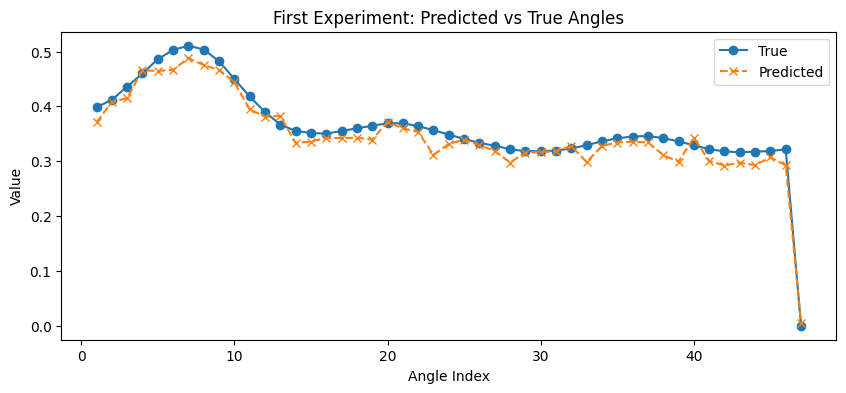

In [34]:
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Take the first experiment (first sample) directly from your dataset
x_first = torch.tensor(X[2:3], dtype=torch.float32).to(device)  # shape (1, 1743, 17)
y_first = torch.tensor(Y[2:3], dtype=torch.float32).to(device)  # shape (1, 47, 1)

with torch.no_grad():
    y_pred_first, attn_first = model(x_first)  # unpack both outputs

# Convert to numpy for plotting
true_vals = y_first.squeeze(0).squeeze(-1).cpu().numpy()    # (47,)
pred_vals = y_pred_first.squeeze(0).squeeze(-1).cpu().numpy()  # (47,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(1, 48), true_vals, 'o-', label='True')
plt.plot(range(1, 48), pred_vals, 'x--', label='Predicted')
plt.title('First Experiment: Predicted vs True Angles')
plt.xlabel('Angle Index')
plt.ylabel('Value')
plt.legend()
plt.show()



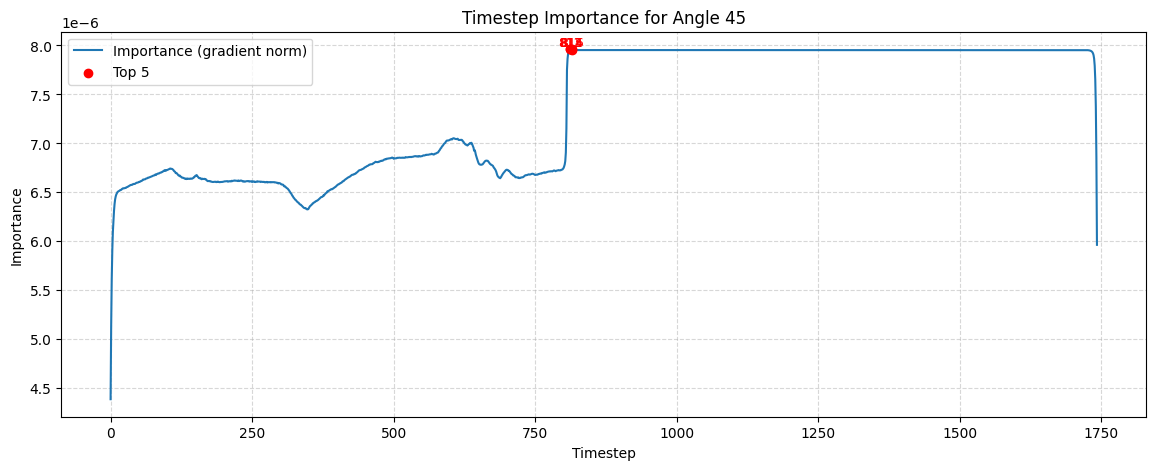

Top 5 timesteps that most influence the angle: [813 812 814 815 816]
Their importance values: [7.961767e-06 7.961196e-06 7.960662e-06 7.959054e-06 7.957498e-06]


In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# ----------------------------
# Select input and angle
# ----------------------------
x_first = torch.tensor(X[0:1], dtype=torch.float32, requires_grad=True).to(device)  # (1, 1743, 17)
angle_idx = 45  # index of the angle to analyze (0-46)

# ----------------------------
# Forward + Backward
# ----------------------------
y_pred, att = model(x_first)  # (1, 47, 1)
target_output = y_pred[0, angle_idx, 0]  # scalar for chosen angle

model.zero_grad()
target_output.backward()

# ----------------------------
# Compute timestep importance
# ----------------------------
grad = x_first.grad.detach().cpu().numpy().squeeze(0)  # (1743, 17)
timesteps_importance = np.linalg.norm(grad, axis=1)    # L2 norm across features (1743,)

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(14,5))
plt.plot(timesteps_importance, label="Importance (gradient norm)")
plt.xlabel("Timestep")
plt.ylabel("Importance")
plt.title(f"Timestep Importance for Angle {angle_idx}")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Highlight top 5 timesteps
top5_idx = np.argsort(timesteps_importance)[-5:][::-1]
plt.scatter(top5_idx, timesteps_importance[top5_idx], 
            color="red", label="Top 5", zorder=5)
for i, idx in enumerate(top5_idx):
    plt.text(idx, timesteps_importance[idx], f"{idx+1}", 
             ha="center", va="bottom", fontsize=9, color="red")

plt.legend()
plt.show()

# ----------------------------
# Print top 5 timesteps
# ----------------------------
print("Top 5 timesteps that most influence the angle:", top5_idx + 1)
print("Their importance values:", timesteps_importance[top5_idx])


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# ----------------------------
# Select input and angle
# ----------------------------
x_first = torch.tensor(X[0:1], dtype=torch.float32, requires_grad=True).to(device)  # (1, 1743, 17)
angle_idx = 0  # index of the angle to analyze (0-46)

# ----------------------------
# Forward pass
# ----------------------------
y_pred = model(x_first)  # (1, 47, 1)
target_output = y_pred[0, angle_idx, 0]  # scalar for chosen angle

# ----------------------------
# Backward pass
# ----------------------------
model.zero_grad()
target_output.backward()  # compute gradients w.r.t input

# ----------------------------
# Compute timestep importance
# ----------------------------
grad = x_first.grad.data.squeeze(0).cpu().numpy()  # (1743, 17)
timesteps_importance = np.linalg.norm(grad, axis=1)  # L2 norm over features → (1743,)

# ----------------------------
# Plot importance
# ----------------------------
plt.figure(figsize=(12,4))
plt.plot(range(1, 1744), timesteps_importance)
plt.xlabel('Timestep')
plt.ylabel('Gradient Norm (importance)')
plt.title(f'Timestep Importance for Angle {angle_idx}')
plt.show()

# ----------------------------
# Optional: print top 5 timesteps
# ----------------------------
top5_idx = np.argsort(timesteps_importance)[-5:][::-1]
print("Top 5 timesteps that most influence the angle:", top5_idx + 1)
print("Their importance values:", timesteps_importance[top5_idx])


TypeError: tuple indices must be integers or slices, not tuple